<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Colaboratory/ICNPG_aleatorios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+git://github.com/andreinechaev/nvcc4jupyter.git


  Cloning git://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-svbmylp4
  Running command git clone -q git://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-svbmylp4
  Created wheel for NVCCPlugin: filename=NVCCPlugin-0.0.2-cp37-none-any.whl size=4305 sha256=5e1ca1aff89cfe23f145817474c546dc579ef41aa3133aea3515a3d9f97293cc
  Stored in directory: /tmp/pip-ephem-wheel-cache-pz0olo_z/wheels/10/c2/05/ca241da37bff77d60d31a9174f988109c61ba989e4d4650516
Successfully built NVCCPlugin


In [ ]:
%load_ext nvcc_plugin

created output directory at /content/src
Out bin /content/result.out


In [ ]:
!nvidia-smi

Mon Jun 21 17:18:23 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 465.27       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   34C    P8    28W / 149W |      0MiB / 11441MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
!pip install cupy-cuda110

     |████████████████████████████████| 165.3MB 84kB/s 


# curand HOST API

Empecemos con la API del host, que puede ser usada para generar un array random en host o en device

In [ ]:
%%cuda --name randomarray.cu
/*
 * This program uses the host CURAND API to generate 100 
 * pseudorandom floats.
 */
 #include <stdio.h>
 #include <stdlib.h>
 #include <cuda.h>
 #include <curand.h>
 
 #define CUDA_CALL(x) do { if((x)!=cudaSuccess) { \
     printf("Error at %s:%d\n",__FILE__,__LINE__);\
     return EXIT_FAILURE;}} while(0)
 #define CURAND_CALL(x) do { if((x)!=CURAND_STATUS_SUCCESS) { \
     printf("Error at %s:%d\n",__FILE__,__LINE__);\
     return EXIT_FAILURE;}} while(0)
 
 int main(int argc, char *argv[])
 {

     size_t n = 100;

     if(argc>1) n=atoi(argv[1]);

     size_t i;
     curandGenerator_t gen;
     float *hostData;
 
     /* Allocate n floats on host */
     hostData = (float *)calloc(n, sizeof(float));
 
    #ifndef CPU
    float *devData; 

     /* Allocate n floats on device */
     CUDA_CALL(cudaMalloc((void **)&devData, n*sizeof(float)));
 
     /* Create pseudo-random number generator */
     CURAND_CALL(curandCreateGenerator(&gen, 
                 CURAND_RNG_PSEUDO_DEFAULT));
     
     /* Set seed */
     CURAND_CALL(curandSetPseudoRandomGeneratorSeed(gen, 
                 1234ULL));
 
     /* Generate n floats on device */
     CURAND_CALL(curandGenerateUniform(gen, devData, n));
 
     /* Copy device memory to host */
     CUDA_CALL(cudaMemcpy(hostData, devData, n * sizeof(float),
         cudaMemcpyDeviceToHost));
    #else    

     /* Create pseudo-random number generator */
     CURAND_CALL(curandCreateGeneratorHost(&gen, 
        CURAND_RNG_PSEUDO_DEFAULT));

     /* Set seed */
     CURAND_CALL(curandSetPseudoRandomGeneratorSeed(gen, 
        1234ULL));

     /* Generate n floats on device */
     CURAND_CALL(curandGenerateUniform(gen, hostData, n));

     #endif

     /* Show result */
     int m=(n>100)?100:n;
     for(i = 0; i < m; i++) {
         printf("%1.4f ", hostData[i]);
     }
     printf("\n");
 
     /* Cleanup */
     CURAND_CALL(curandDestroyGenerator(gen));
 
     #ifndef CPU
     CUDA_CALL(cudaFree(devData));
     #endif
     free(hostData);    

     return EXIT_SUCCESS;
 }
 

'File written in /content/src/randomarray.cu'

In [ ]:
!nvcc /content/src/randomarray.cu -o /content/src/random -lcurand
! /content/src/random

0.1455 0.8202 0.5504 0.2948 0.9147 0.8690 0.3219 0.7829 0.0113 0.2855 0.7816 0.2338 0.6791 0.2824 0.6299 0.1212 0.4333 0.3831 0.5136 0.2987 0.4166 0.0345 0.0494 0.0467 0.6166 0.6480 0.8685 0.4012 0.0631 0.4972 0.6809 0.9350 0.0704 0.0458 0.1324 0.3785 0.6457 0.9930 0.9952 0.7677 0.3217 0.8210 0.2765 0.2691 0.4579 0.1969 0.9555 0.8739 0.7996 0.3810 0.6662 0.3153 0.9428 0.5006 0.3369 0.1490 0.8637 0.6191 0.6820 0.4573 0.9261 0.5650 0.7117 0.8252 0.8755 0.2216 0.2958 0.4046 0.3896 0.7335 0.7301 0.8154 0.0913 0.0866 0.6974 0.1811 0.5834 0.9255 0.9029 0.0413 0.9522 0.5507 0.7237 0.3976 0.7519 0.4398 0.4638 0.6094 0.7358 0.3272 0.6961 0.4893 0.9698 0.0456 0.2025 0.9491 0.1516 0.0424 0.6149 0.5638 


Si definimos el macro CPU en la compilacion podemos generar directamente en el host

In [ ]:
!nvcc /content/src/randomarray.cu -o /content/src/random -lcurand -DCPU
! /content/src/random

0.1455 0.8202 0.5504 0.2948 0.9147 0.8690 0.3219 0.7829 0.0113 0.2855 0.7816 0.2338 0.6791 0.2824 0.6299 0.1212 0.4333 0.3831 0.5136 0.2987 0.4166 0.0345 0.0494 0.0467 0.6166 0.6480 0.8685 0.4012 0.0631 0.4972 0.6809 0.9350 0.0704 0.0458 0.1324 0.3785 0.6457 0.9930 0.9952 0.7677 0.3217 0.8210 0.2765 0.2691 0.4579 0.1969 0.9555 0.8739 0.7996 0.3810 0.6662 0.3153 0.9428 0.5006 0.3369 0.1490 0.8637 0.6191 0.6820 0.4573 0.9261 0.5650 0.7117 0.8252 0.8755 0.2216 0.2958 0.4046 0.3896 0.7335 0.7301 0.8154 0.0913 0.0866 0.6974 0.1811 0.5834 0.9255 0.9029 0.0413 0.9522 0.5507 0.7237 0.3976 0.7519 0.4398 0.4638 0.6094 0.7358 0.3272 0.6961 0.4893 0.9698 0.0456 0.2025 0.9491 0.1516 0.0424 0.6149 0.5638 


Como usamos la misma semilla para ambos, tiene sentido tener los mismos numeros.

Ejercicios: 
* Timming CPU vs GPU.
* Verificar distribución.
* Cambiar distribución.      


# Calcular $\pi$ con numeros aleatorios

Empecemos en C++, usando curand y thrust, pero usando la HOST API.

In [ ]:
%%cuda --name Pi_curand.cu

 #include <iostream>
 #include <stdlib.h>
 #include <cuda.h>
 #include <curand.h>
 #include <thrust/device_vector.h>
 #include <thrust/count.h>

 #define CUDA_CALL(x) do { if((x)!=cudaSuccess) { \
     printf("Error at %s:%d\n",__FILE__,__LINE__);\
     return EXIT_FAILURE;}} while(0)
 #define CURAND_CALL(x) do { if((x)!=CURAND_STATUS_SUCCESS) { \
     printf("Error at %s:%d\n",__FILE__,__LINE__);\
     return EXIT_FAILURE;}} while(0)
 

struct dentroCuadradoUnidad
{
    __host__ __device__
    bool operator()(thrust::tuple<float,float> tup)
    {
        float x=thrust::get<0>(tup);
        float y=thrust::get<1>(tup);
        return (x*x+y*y)<1;
    }
};

 int main(int argc, char *argv[])
 {
    size_t n = 10000000;
    curandGenerator_t gen;
 
    thrust::device_vector<float> devData(n);

     /* Create pseudo-random number generator */
     CURAND_CALL(curandCreateGenerator(&gen, 
                 CURAND_RNG_PSEUDO_DEFAULT));
     
     /* Set seed */
     CURAND_CALL(curandSetPseudoRandomGeneratorSeed(gen, 
                 1234ULL));
 
    /* Generate n floats on device */
    float *devData_raw=thrust::raw_pointer_cast(&devData[0]);
    CURAND_CALL(curandGenerateUniform(gen, devData_raw, n));
  
    // usamos la primera mitad como x, la segunda como y
    int adentro = thrust::count_if(
        thrust::make_zip_iterator((thrust::make_tuple(devData.begin(),devData.begin()+n/2))),
        thrust::make_zip_iterator((thrust::make_tuple(devData.begin()+n/2,devData.begin()+n))),
        dentroCuadradoUnidad()
    );    

    /*
    dardos adentro = rho pi R^2/4 
    dardos total = rho R^2
    4*adentro/total = pi
    */

    // hay n/2 dardos ->
    std::cout << 4.0*adentro*(2.0/n) << std::endl;
 
     /* Cleanup */
     CURAND_CALL(curandDestroyGenerator(gen));
     return EXIT_SUCCESS;
 }

'File written in /content/src/Pi_curand.cu'

In [ ]:
!nvcc /content/src/Pi_curand.cu -o /content/src/Pi_curand -lcurand
! /content/src/Pi_curand

terminate called after throwing an instance of 'thrust::system::system_error'
  what():  after reduction step 1: cudaErrorInvalidDeviceFunction: invalid device function


Ahora hagamoslo con cupy, usando tambien la HOST API, y comparemos con numpy

In [ ]:
import cupy as cp
import numpy as np
from cupyx.time import repeat

def piCPU(n):
    ## en CPU
    data = np.random.uniform(-0.5,0.5,(n,2))

    inside = len(
        np.argwhere(
            np.linalg.norm(data, axis=1) < 0.5
        )
    )
    print(inside/n*4)

def piGPU(n):
    ## en GPU
    dataGPU = cp.random.uniform(-0.5,0.5,(n,2))

    inside = len(
        cp.argwhere(
            cp.linalg.norm(dataGPU, axis=1) < 0.5
        )
    )
    print(inside/n*4)

n=10000000

# esto lo vamos a probar en mi maquina
print(repeat(piCPU, (n,), n_repeat=10)) 
print(repeat(piGPU, (n,), n_repeat=10)) 

#piCPU(n)
#piGPU(n)


ImportError: ignored

Ejercicio:
* Comparen la performance para distintos $n$

# Calcular $\pi$ usando la DEVICE API 

In [ ]:
%%cuda --name pi.cu

#include <thrust/iterator/counting_iterator.h>
#include <thrust/functional.h>
#include <thrust/transform_reduce.h>
#include <curand_kernel.h>

#include <iostream>
#include <iomanip>

#define GLOBALSEED  12345

// we could vary M & N to find the perf sweet spot

struct estimate_pi : 
    public thrust::unary_function<unsigned int, float>
{
  __device__
  float operator()(unsigned int thread_id)
  {
    float sum = 0;
    unsigned int N = 10000; // samples per thread
    unsigned int seed = thread_id;

    curandStatePhilox4_32_10_t s;

    // seed a random number generator
    curand_init(GLOBALSEED,seed, 0, &s);

    // take N samples in a quarter circle
    for(unsigned int i = 0; i < N; ++i)
    {
      // draw a sample from the unit square
      float x = curand_uniform(&s);
      float y = curand_uniform(&s);

      // measure distance from the origin
      float dist2 = (x*x + y*y);

      // add 1.0f if (u0,u1) is inside the quarter circle
      if(dist2 <= 1.0f)
        sum += 1.0f;
    }

    // multiply by 4/N to get the area of the whole circle
    sum *= 4.0f/N;

    return sum;
  }
};

int main(void)
{
  // use 30K independent seeds
  int M = 30000;

  float estimate = thrust::transform_reduce(
        thrust::counting_iterator<int>(0),
        thrust::counting_iterator<int>(M),
        estimate_pi(),
        0.0f,
        thrust::plus<float>());
  estimate /= M;

  std::cout << std::setprecision(6);
  std::cout << "pi is approximately ";
  std::cout << estimate << std::endl;
  return 0;
}

//if(thread_id<=2) printf("%d %d %d\n",thread_id,s.key.x,s.ctr.x);
//if(thread_id<=2) printf("%d %d %d\n",thread_id,s.key.x,s.ctr.x);


UsageError: Cell magic `%%cuda` not found.


In [ ]:
!nvcc -lcurand /content/src/pi.cu -o /content/src/pi
!/content/src/pi

gcc: error: /content/src/pi.cu: No such file or directory
gcc: warning: ‘-x c++’ after last input file has no effect
gcc: fatal error: no input files
compilation terminated.
/bin/bash: /content/src/pi: No such file or directory


# Metropolis Monte Carlo

In [ ]:
%%cuda --name miniising.cu

/*
Resuelve el modelo de Ising con el metodo de metropolis MonteCarlo. 
Es decir, genera una cadena de Markov que samplea configuraciones 
{S_1,...,S_N} con energias

H = - \sum_{<ij>} S_i S_j

donde \sum_<ij> denota suma sobre pares de primetos vecinos,
y S_i=+-1 el "spin". El metodo de MonteCarlo garantiza 
que para un numero de "updates" lo suficientemente grande, 
las configuraciones son sampleadas segun su peso de Boltzmann 

P~exp[-H/T]

permitiendo hacer promedios termodinamicos de equilibrio.
En particular, la magnetizacion por sitio en funcion de la temperatura

M = \sum_i S_i/N

con N=L*L el numero total de sitios en una 
red cuadrada de LxL.

La estrategia de paralelizacion es la del tablero de ajedrez:
hacemo un updates paralelo de todas las fichas blancas, seguido 
por uno de todas las negras. 

Se puede demostrar que la cadena de Markov converge a equilibrio.
*/

#include<iostream> //input-output pantalla
#include<fstream> //input-output disco
#include<cstdlib> // atoi, atof, etc
#include <unistd.h> // getop
#include <cmath> 

/*#include "gpu_timer.h"
#include "cpu_timer.h"
*/

// thrust
#include<thrust/host_vector.h>
#include<thrust/device_vector.h>
#include <thrust/tuple.h>
#include <thrust/transform.h>
#include <thrust/functional.h>
#include <thrust/execution_policy.h>
#include<thrust/iterator/counting_iterator.h>

/* counter-based random numbers */
// http://www.thesalmons.org/john/random123/releases/1.06/docs/

#ifdef RANDOM123
#include <Random123/philox.h> // philox headers
#include <Random123/u01.h>    // to get uniform deviates [0,1]
typedef r123::Philox2x32 RNG; // particular counter-based RNG
#else 
#include <curand_kernel.h>
#endif


#ifdef RANDOM123
// functor para obtener numeros aleatorios uniformes en [0,1]
// a partir de un key (sitio), un global seed, y un tiempo 
__device__
float uniform(int n, int seed, int t)
{
		// keys and counters 
		RNG philox; 	
		RNG::ctr_type c={{}};
		RNG::key_type k={{}};
		RNG::ctr_type r;
		// Garantiza una secuencia random "unica" para cada thread	
		k[0]=n;    // distintos sitios, distintos numeros random!
		c[1]=seed; // seed global, necesario para decidir reproducir secuencia, o no...
		c[0]=t;    // el seed tiene que cambiar con la iteracion, sino...
		r = philox(c, k); // son dos numeros random, usaremos uno solo r[0]
		return (u01_closed_closed_32_53(r[0])); // funcion adaptadora a [0,1]
}
#else
__device__
float uniform(int n, int seed, int t)
{
    //curandState s; // el default
    curandStatePhilox4_32_10_t s;
 
    curand_init(n, seed, t, &s);
 
    return curand_uniform(&s);
}
#endif


// functor tipo predicado: cada thread determina si su sitio es del "color" 0 o 1
// necesario para "transform_if"
struct ficha
{
	bool color;
	int L;
	ficha(bool _color, int _L):color(_color),L(_L){};

	__device__ __host__
	bool operator()(int n){
		return ((n%L+int(n/L))%2==color); // true si n es color
	}	
};

// functor: cada thread hace el metropolis update de su sitio
// ejemplo para modelo de Ising con interaccion de primeros vecinos
struct metropolis
{
	int L;
	float T;
	int *Mptr;
	int t;
	int seed;
	metropolis(int * _Mptr, float _T, int _L, int _t, int _seed):
	Mptr(_Mptr),T(_T),L(_L),t(_t),seed(_seed){};	

	__device__
	int operator()(int n){

		int nx=n%L;
	       	int ny=int(n/L);

		int local_field=
		Mptr[(nx-1+L)%L  + ny*L] + Mptr[(nx+1+L)%L  + ny*L] +
		Mptr[nx+((ny+1+L)%L)*L]  + Mptr[nx+((ny-1+L)%L)*L];

		// contribucion de nuestro spin sin flipear a la energia  
		float ene0=-Mptr[n]*local_field;	

		// contribucion a la energia de nuestro spin flipeado
		//int ene1=M[n]*vecinos;
		float ene1=Mptr[n]*local_field;	

		// metropolis: aceptar flipeo solo si r < exp(-(ene1-ene0)/temp)
		float p=exp(-(ene1-ene0)/T);

		// numero random entre [0,1] uniforme
		float rn = uniform(n, seed, t);

		// metropolis update segun regla de acceptancia 
		return (rn<p)?(-Mptr[n]):(Mptr[n]);
	}	
};

// imprime toda la red de sitios en pantalla
void print_campo_de_magnetizacion(thrust::device_vector<int> &M, int L, std::ofstream &fout)
{
	fout << "\n";
	for(int ny=0;ny<L;ny++){
		for(int nx=0;nx<L;nx++){
			fout << M[nx+ny*L] << "\t"; 
		}
		fout << std::endl;
	}
}

/*
COMPILACION:
nvcc miniising.cu
*/
int main(int argc, char **argv)
{
	int globalseed=123456; // semilla global generador paralelo
	int L=512; // largo red cuadrada
	float T=1.0; // temperatura
	int nrun=1000; // numero total de pasos de MonteCarlo
	int tsnap=nrun+1; // cada cuando imprimo configs
	std::ofstream fout("movie.dat"); // fichero para guardar configs
	std::ofstream mout("mag.dat"); // fichero para guardar magnetizacion por sitio vs tiempo

	// para tomar opciones de la linea de comandos
	int opt;
	while ((opt = getopt(argc, argv, "l:r:T:s:w:")) != -1) 
	{
               switch (opt) {
               case 'l':
                   L = atoi(optarg);
                   break;
               case 'r':
                   nrun = atoi(optarg);
                   break;
               case 'T':
                   T = atof(optarg);
                   break;
               case 's':
                   globalseed = atoi(optarg);
                   break;
               case 'w':
                   tsnap = atoi(optarg);
                   break;
               default: /* '?' */
                   fprintf(stderr, "Uso: %s [-l L] [-r niter] [-T temp] [-s semilla] [-w snap]\n", argv[0]);
                   exit(EXIT_FAILURE);
               }
	}

	std::ofstream logout("log.dat"); // fichero para guardar configs
	logout << "L=" << L << ", ";
	logout << "nrun=" << nrun << ", ";
	logout << "T=" << T << ", ";
	logout << "globalseed= " << globalseed << " ";
	logout << "tsnap= " << tsnap << "\n";	
	std::cout << "L=" << L << ", ";
	std::cout << "nrun=" << nrun << ", ";
	std::cout << "T=" << T << ", ";
	std::cout << "globalseed= " << globalseed << " ";
	std::cout << "tsnap= " << tsnap << "\n";	
	#ifdef _OPENMP
  	logout << "#host OMP threads = " << omp_get_max_threads() << std::endl;
  	std::cout << "#host OMP threads = " << omp_get_max_threads() << std::endl;
  	#elif defined(__CUDACC__)
  	int card;
  	cudaGetDevice(&card);
  	cudaDeviceProp deviceProp;
  	cudaGetDeviceProperties(&deviceProp, card);
  	logout << "\nDevice Selected " << card << " " << deviceProp.name << "\n";
	std::cout << "\nDevice Selected " << card << " " << deviceProp.name << "\n";
	#else
	std::cout << "\nCPU serial\n";
	logout << "\nCPU serial\n";
  	#endif

	/**************************************************/
	// AHORA EMPIEZA LO IMPORTANTE


	if(L%2==1) std::cout << "warning: para usar checkerboard L debe ser par" << std::endl;

	int N=L*L;

	// vector de magnetizacion en la red
	thrust::device_vector<int> M(N);
	int *Mraw=thrust::raw_pointer_cast(M.data()); // puntero crudo

  srand(12345);
	// condicion inicial random, usando generador standard de C
	for(int n=0;n<N;n++) M[n]=(rand()*1.0/RAND_MAX>0.5)?(1):(-1);


	//cpu_timer crono;
	//crono.tic();

	// loop de pasos de MonteCarlo
	for(int nt=0;nt<nrun;nt++)
	{
		//ojo!: lento, GPU->CPU->disco de mucha info! (hacer cada muchos pasos)
		if((nt+1)%tsnap==0) print_campo_de_magnetizacion(M, L, fout);

		// imprime magnetizacion por sitio (usando parallel reduction)
		mout << thrust::reduce(M.begin(),M.end())*1.0/N << std::endl;

		for(int color=0;color<2;color++){ // "checkerboard decomposition"
			// update de sitios de color "color" usando transform_if paralelo

      // TODO: escribir un kernel que haga lo mismo
			thrust::transform_if(
				thrust::make_counting_iterator(0), thrust::make_counting_iterator(N), //rango
				M.begin(), // output
				metropolis(Mraw,T,L,nt,globalseed), // operacion 
				ficha(color, L) // predicado
			);


		}
	}

	//std::cout << "ms = " << crono.tac() << std::endl;
	//logout << "ms = " << crono.tac() << std::endl;


	return 0;
}


'File written in /content/src/miniising.cu'

In [ ]:
!nvcc -DRANDOM123 -lcurand /content/src/miniising.cu -o /content/src/miniisingR123 -I/content/drive/MyDrive/Classroom/Introducción\ al\ Cálculo\ Numérico\ en\ Procesadores\ Gráficos\ Materia\ Optativa/Codigos_de_las_Clases/common
!nvcc -lcurand /content/src/miniising.cu -o /content/src/miniisingCUR -I/content/drive/MyDrive/Classroom/Introducción\ al\ Cálculo\ Numérico\ en\ Procesadores\ Gráficos\ Materia\ Optativa/Codigos_de_las_Clases/common


In [ ]:
!/content/src/miniisingR123 -T 1.2; mv mag.dat magR123.dat
!/content/src/miniisingCUR -T 1.2; mv mag.dat magCUR.dat


L=512, nrun=1000, T=1.2, globalseed= 123456 tsnap= 1001

Device Selected 0 Tesla T4
L=512, nrun=1000, T=1.2, globalseed= 123456 tsnap= 1001

Device Selected 0 Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


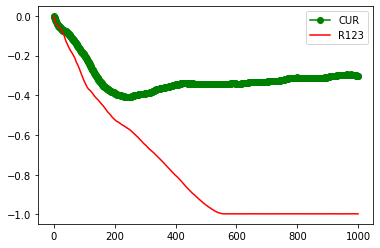

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
Mag=np.loadtxt('/content/magCUR.dat')
plt.plot(Mag,'g-o',label="CUR")

Mag0=np.loadtxt('/content/magR123.dat')
plt.plot(Mag0,"r-",label="R123")

plt.legend()

plt.show()

# Tareas
* Usar curand en vez de Random123
* transformar el transform_if a un kernel